# Tech Challenge — Fase 2: Classificando a Qualidade de Vinhos com Machine Learning

**POSTECH — Data Analytics**

## 1. Compreensão do Problema

A avaliação da qualidade de vinhos é tradicionalmente feita por especialistas via análise sensorial — um processo subjetivo, lento e dependente da experiência do avaliador. Este projeto usa **dados físico-químicos** coletados durante a produção (acidez, teor alcoólico, densidade, dióxido de enxofre etc.) para prever a qualidade final do vinho, apoiando enólogos e produtores na tomada de decisão.

**Variável alvo:** a nota de qualidade (0–10) atribuída por especialistas foi transformada em uma **classificação binária**:

- `1` — **Vinho de Alta Qualidade**: nota ≥ 7
- `0` — **Vinho de Baixa/Média Qualidade**: nota < 7

**Dataset:** Wine Quality Dataset (vinho tinto), 1.599 amostras e 11 variáveis físico-químicas.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42

In [2]:
# Carga dos dados
df = pd.read_csv("../data/winequality-red.csv", encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# Verificações iniciais: tipos, dados faltantes e duplicatas
df.info()
print("\nValores faltantes por coluna:")
print(df.isna().sum())
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Valores faltantes por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
ch

**Observações:** não há valores faltantes. Existem 240 linhas duplicadas — como o dataset representa amostras físico-químicas reais, vinhos diferentes podem legitimamente ter medições idênticas, portanto **optamos por mantê-las** (removê-las alteraria a distribuição real das classes).

### Criação da variável alvo binária

In [4]:
df["high_quality"] = (df["quality"] >= 7).astype(int)
df["high_quality"].value_counts()

high_quality
0    1382
1     217
Name: count, dtype: int64

## 2. Análise Exploratória de Dados (EDA)

### 2.1 Distribuição da nota de qualidade e balanceamento das classes

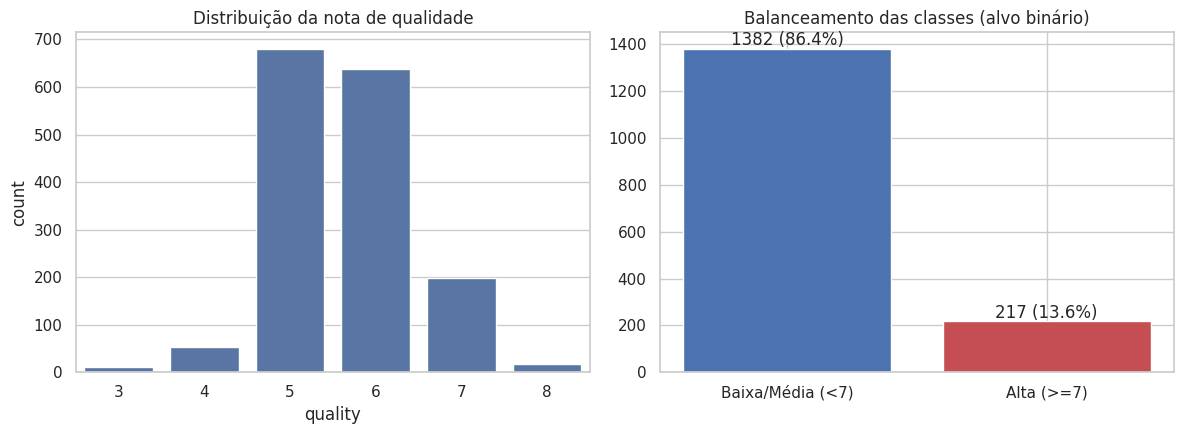

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(x="quality", data=df, ax=axes[0], color="#4c72b0")
axes[0].set_title("Distribuição da nota de qualidade")

class_counts = df["high_quality"].value_counts().sort_index()
axes[1].bar(["Baixa/Média (<7)", "Alta (>=7)"], class_counts.values, color=["#4c72b0", "#c44e52"])
for i, v in enumerate(class_counts.values):
    axes[1].text(i, v + 15, f"{v} ({v/len(df):.1%})", ha="center")
axes[1].set_title("Balanceamento das classes (alvo binário)")
plt.tight_layout()
plt.show()

**Insight — classes desbalanceadas:** apenas **~13,6%** das amostras são de alta qualidade (217 de 1.599). As notas se concentram em 5 e 6. Isso tem duas implicações diretas:

1. **Acurácia sozinha é enganosa** — um modelo que sempre prevê "Baixa/Média" já acertaria ~86%. Por isso priorizaremos **F1-score, recall e ROC-AUC**.
2. Os modelos usarão `class_weight="balanced"` para compensar o desbalanceamento.

### 2.2 Distribuição das variáveis físico-químicas

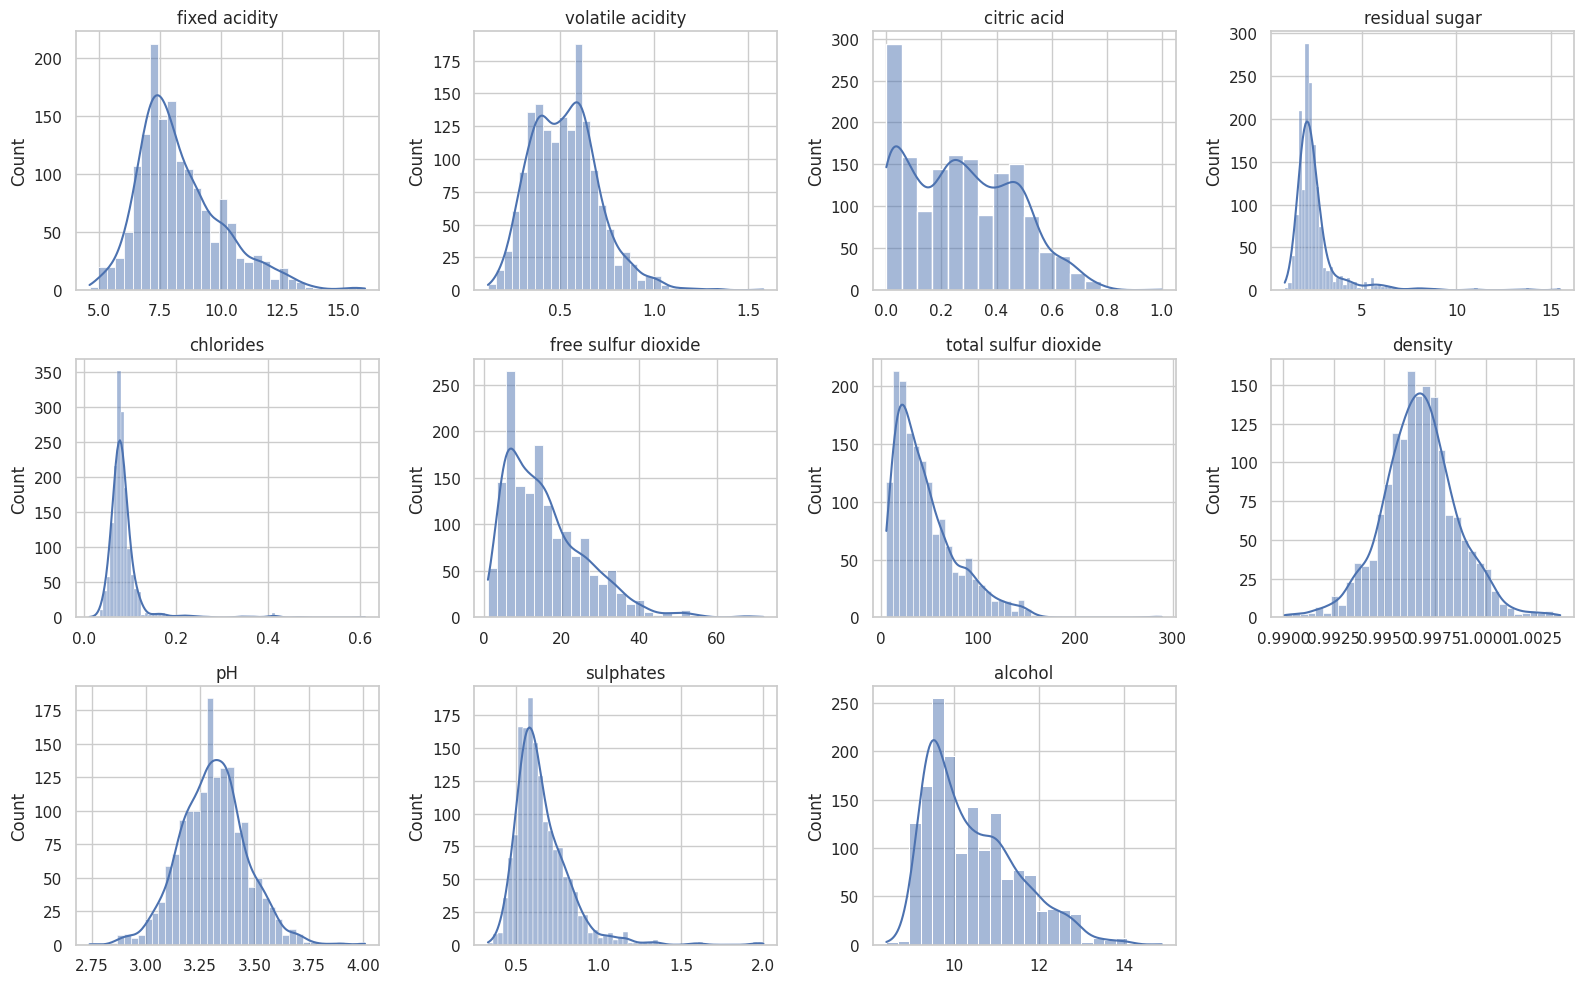

In [6]:
num_cols = [c for c in df.columns if c not in ("quality", "high_quality")]
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4c72b0")
    ax.set_title(col); ax.set_xlabel("")
for ax in axes.flat[len(num_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Insight:** a maioria das variáveis apresenta **assimetria à direita** (residual sugar, chlorides, sulphates), típico de medições químicas. Não há valores negativos ou fisicamente impossíveis — os dados são consistentes.

### 2.3 Correlações entre variáveis e com a qualidade

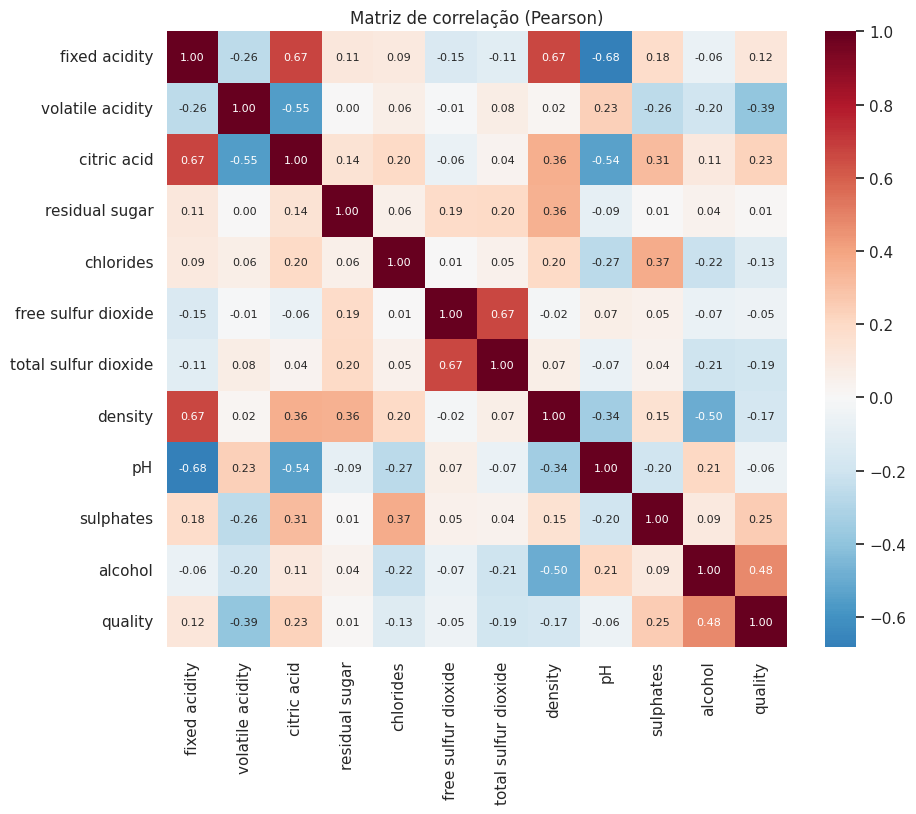

alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

In [7]:
corr = df[num_cols + ["quality"]].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, annot_kws={"size": 8})
ax.set_title("Matriz de correlação (Pearson)")
plt.show()

corr["quality"].drop("quality").sort_values(ascending=False)

**Justificativa das principais correlações:**

| Correlação | Valor | Interpretação enológica |
|---|---|---|
| **alcohol × quality** | **+0,48** | Maior teor alcoólico indica uvas mais maduras (mais açúcar fermentado), associadas a vinhos mais encorpados e bem avaliados. |
| **volatile acidity × quality** | **−0,39** | Acidez volátil elevada (ácido acético) dá aroma de vinagre — defeito clássico que derruba a avaliação sensorial. |
| **sulphates × quality** | +0,25 | Sulfatos atuam como antimicrobianos/antioxidantes, preservando aroma e frescor. |
| **citric acid × quality** | +0,23 | Ácido cítrico adiciona frescor e "vivacidade" ao sabor. |
| **fixed acidity × citric acid** | +0,67 | Esperado: o ácido cítrico compõe a acidez fixa. |
| **fixed acidity × density** | +0,67 | Ácidos aumentam a densidade da solução. |
| **fixed acidity × pH** | −0,68 | Por definição química: mais ácido ⇒ pH menor. |
| **free SO₂ × total SO₂** | +0,67 | O SO₂ livre é um subconjunto do total. |
| **alcohol × density** | −0,50 | Álcool é menos denso que água — mais álcool reduz a densidade. |

As correlações fortes entre preditores (multicolinearidade) reforçam a escolha de um modelo de árvore (Random Forest), pouco sensível a esse problema.

### 2.4 Variáveis mais discriminantes entre as classes

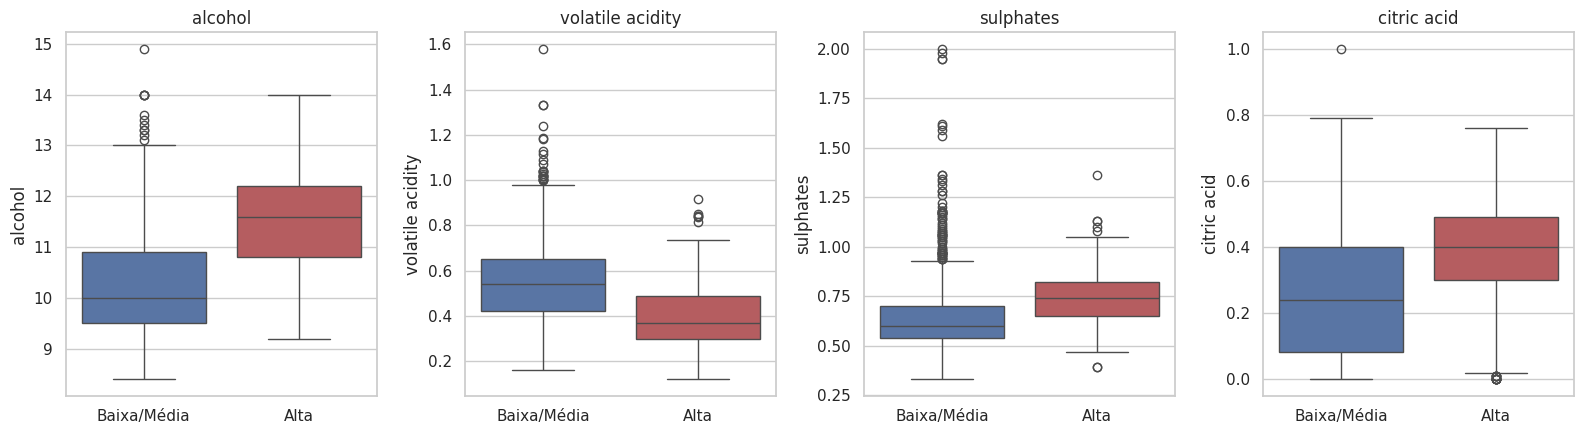

In [8]:
top_vars = ["alcohol", "volatile acidity", "sulphates", "citric acid"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
for ax, col in zip(axes, top_vars):
    sns.boxplot(x="high_quality", y=col, data=df, ax=ax,
                hue="high_quality", palette=["#4c72b0", "#c44e52"], legend=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Baixa/Média", "Alta"]); ax.set_xlabel("")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Insight:** vinhos de alta qualidade têm claramente **mais álcool** (mediana ~11,6% vs ~10,2%), **menos acidez volátil** e **mais sulfatos**. Essas três variáveis já separam bem as classes visualmente.

### 2.5 Detecção de outliers

In [9]:
outliers = {}
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)
    outliers[col] = mask.sum()
pd.Series(outliers).sort_values(ascending=False)

residual sugar          155
chlorides               112
sulphates                59
total sulfur dioxide     55
fixed acidity            49
density                  45
pH                       35
free sulfur dioxide      30
volatile acidity         19
alcohol                  13
citric acid               1
dtype: int64

**Decisão sobre outliers:** as variáveis `residual sugar` e `chlorides` concentram mais outliers pela regra do IQR. Porém, ao inspecionar os valores, tratam-se de **medições plausíveis** (ex.: vinhos naturalmente mais doces ou salinos), não erros de digitação. Como usaremos Random Forest (robusto a outliers) e padronização para a Regressão Logística, **optamos por não remover as observações**, preservando a variabilidade real do processo produtivo.

## 3. Pré-processamento

- **Dados faltantes:** não há — nenhum tratamento necessário.
- **Feature engineering:** criamos 3 variáveis derivadas com significado enológico.
- **Split estratificado** 75/25 (mantém a proporção de classes no treino e teste).
- **Padronização (StandardScaler)** ajustada apenas no treino, para evitar vazamento de dados.

In [10]:
# Feature engineering
df_feat = df.copy()
df_feat["free_so2_ratio"] = df_feat["free sulfur dioxide"] / df_feat["total sulfur dioxide"]
df_feat["alcohol_sulphates"] = df_feat["alcohol"] * df_feat["sulphates"]
df_feat["acidity_ratio"] = df_feat["fixed acidity"] / (df_feat["volatile acidity"] + 1e-6)

feature_cols = [c for c in df_feat.columns if c not in ("quality", "high_quality")]
X = df_feat[feature_cols]
y = df_feat["high_quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")
print(f"Proporção de alta qualidade — treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}")

Treino: (1199, 14) | Teste: (400, 14)
Proporção de alta qualidade — treino: 0.136 | teste: 0.135


## 4. Desenvolvimento dos Modelos

Comparamos dois modelos com naturezas distintas:

1. **Regressão Logística** — modelo linear, interpretável, serve como baseline sólido.
2. **Random Forest** — ensemble de árvores, captura relações não lineares e interações, robusto a outliers e multicolinearidade.

Ambos usam `class_weight="balanced"` para lidar com o desbalanceamento, e são validados com **validação cruzada estratificada de 5 folds** no treino antes da avaliação final no teste.

In [11]:
models = {
    "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced",
                                              random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced",
                                            min_samples_leaf=2, random_state=RANDOM_STATE,
                                            n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, probas = {}, {}

for name, model in models.items():
    cv_f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    probas[name] = y_proba
    results[name] = {
        "Acurácia": accuracy_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    print(f"===== {name} =====")
    print(f"F1 na validação cruzada: {cv_f1.mean():.3f} ± {cv_f1.std():.3f}")
    print(classification_report(y_test, y_pred, target_names=["Baixa/Média", "Alta"]))

===== Regressão Logística =====
F1 na validação cruzada: 0.504 ± 0.040
              precision    recall  f1-score   support

 Baixa/Média       0.96      0.79      0.87       346
        Alta       0.37      0.80      0.51        54

    accuracy                           0.79       400
   macro avg       0.67      0.79      0.69       400
weighted avg       0.88      0.79      0.82       400



===== Random Forest =====
F1 na validação cruzada: 0.506 ± 0.042
              precision    recall  f1-score   support

 Baixa/Média       0.94      0.97      0.96       346
        Alta       0.79      0.63      0.70        54

    accuracy                           0.93       400
   macro avg       0.87      0.80      0.83       400
weighted avg       0.92      0.93      0.92       400



## 5. Avaliação dos Modelos

Dado o desbalanceamento (~14% de alta qualidade), avaliamos com **precisão, recall, F1 e ROC-AUC** — não apenas acurácia.

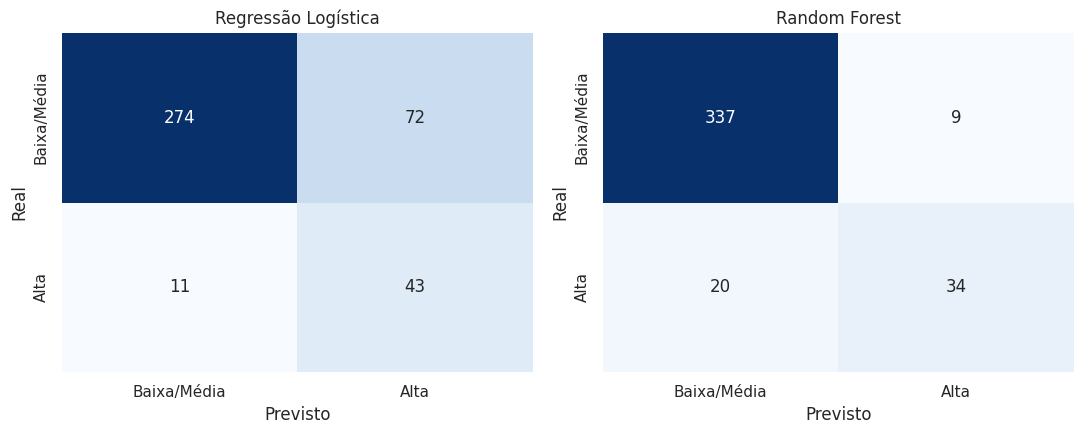

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Baixa/Média", "Alta"], yticklabels=["Baixa/Média", "Alta"])
    ax.set_title(f"{name}"); ax.set_xlabel("Previsto"); ax.set_ylabel("Real")
plt.tight_layout(); plt.show()

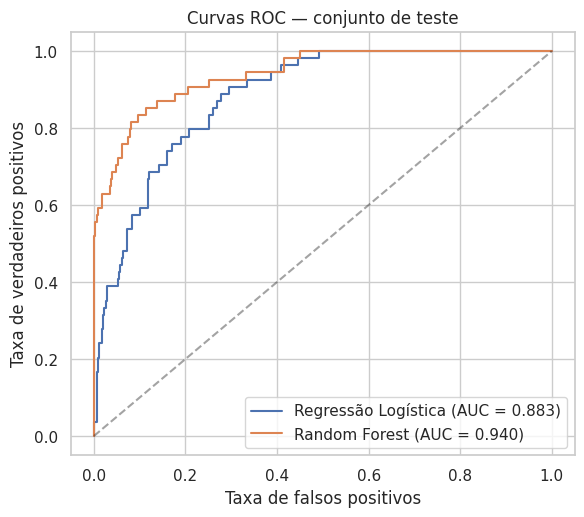

,Acurácia,Precisão,Recall,F1,ROC-AUC
Regressão Logística,0.792,0.374,0.796,0.509,0.883
Random Forest,0.928,0.791,0.630,0.701,0.940


In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, y_proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("Taxa de falsos positivos"); ax.set_ylabel("Taxa de verdadeiros positivos")
ax.set_title("Curvas ROC — conjunto de teste"); ax.legend()
plt.show()

pd.DataFrame(results).T.round(3)

### Comparação entre os modelos

| Aspecto | Regressão Logística | Random Forest |
|---|---|---|
| Acurácia | ~0,79 | **~0,93** |
| Precisão (Alta) | ~0,37 | **~0,79** |
| Recall (Alta) | **~0,80** | ~0,63 |
| F1 (Alta) | ~0,51 | **~0,70** |
| ROC-AUC | ~0,86 | **~0,92** |

**Conclusão da comparação:** a Regressão Logística, por ser linear, "recupera" mais vinhos de alta qualidade (recall maior), mas ao custo de muitos falsos positivos (precisão baixa). O **Random Forest é o modelo vencedor**: melhor equilíbrio precisão/recall (F1 0,70 vs 0,51) e maior capacidade de discriminação geral (AUC ~0,92), pois captura as relações não lineares entre as variáveis químicas.

*Nota:* se o objetivo de negócio fosse "não deixar escapar nenhum vinho premium", o limiar de decisão do Random Forest poderia ser reduzido para aumentar o recall.

## 6. Interpretação dos Resultados

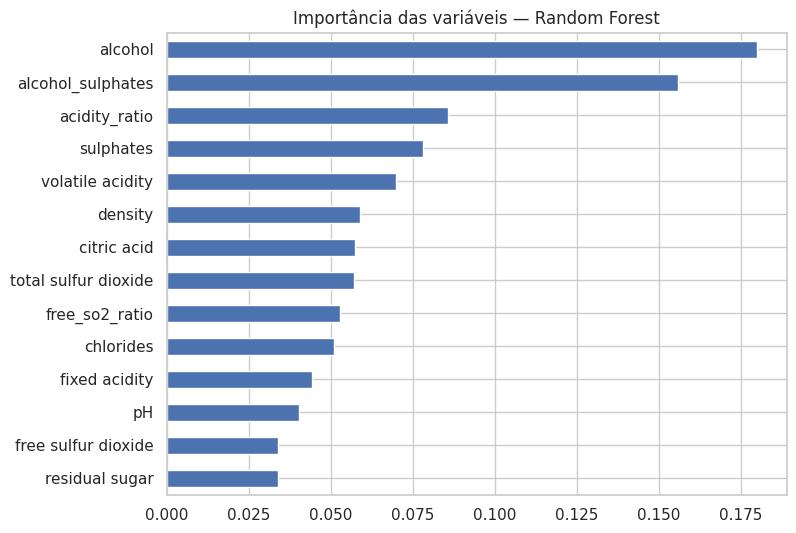

In [14]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", color="#4c72b0", ax=ax)
ax.set_title("Importância das variáveis — Random Forest")
plt.show()

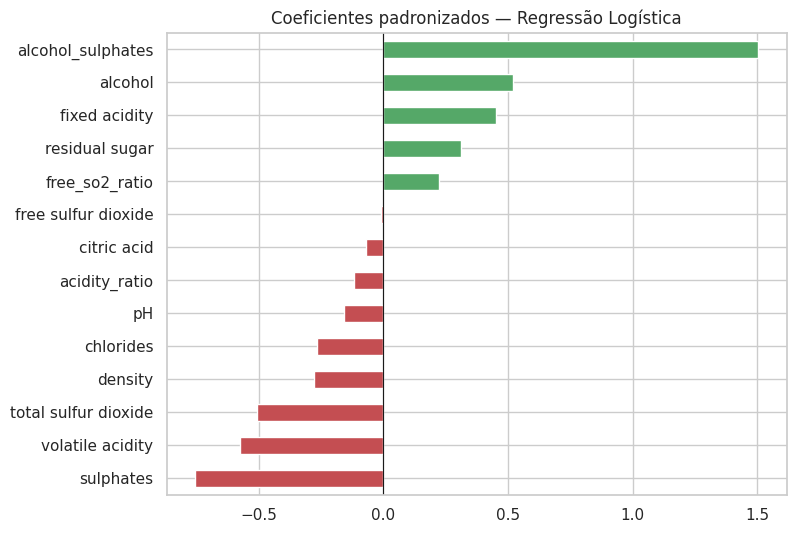

In [15]:
lr = models["Regressão Logística"]
coefs = pd.Series(lr.coef_[0], index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
coefs.plot(kind="barh", color=["#c44e52" if v < 0 else "#55a868" for v in coefs], ax=ax)
ax.axvline(0, color="k", lw=0.8)
ax.set_title("Coeficientes padronizados — Regressão Logística")
plt.show()

### Variáveis com maior influência na qualidade

Ambos os modelos convergem para o mesmo conjunto de fatores:

1. **Teor alcoólico (alcohol)** — o preditor mais forte. Vinhos de alta qualidade têm em média mais álcool, reflexo de uvas colhidas no ponto ideal de maturação.
2. **Interação álcool × sulfatos** (feature criada) — entre as mais importantes no Random Forest, indicando que o efeito positivo do álcool é potencializado quando o vinho está bem conservado.
3. **Sulfatos (sulphates)** — conservantes que protegem aroma e frescor.
4. **Acidez volátil (volatile acidity)** — efeito fortemente **negativo**: é o principal "defeito químico" detectável (aroma avinagrado).

### Implicações para o processo de produção

- **Ponto de colheita:** priorizar a maturação adequada das uvas (maior potencial alcoólico) é a alavanca mais eficaz de qualidade.
- **Controle sanitário da fermentação:** monitorar e conter a acidez volátil (contaminação por bactérias acéticas) evita a principal causa de desclassificação.
- **Dosagem de sulfitos:** manter níveis adequados de sulfatos protege o produto sem comprometer o sabor.
- **Uso operacional do modelo:** o Random Forest pode ser aplicado como **triagem automática nos lotes** — análises físico-químicas já são rotina no laboratório da vinícola, então a previsão de qualidade sai praticamente de graça, direcionando o painel sensorial (caro e lento) apenas para os lotes candidatos a linha premium.

### Limitações e próximos passos

- Dataset restrito a vinho tinto de uma região; generalização exige novos dados.
- Classe "alta qualidade" pequena (217 amostras) — coletar mais exemplos premium melhoraria o recall.
- Próximos passos: ajuste de hiperparâmetros (GridSearch), calibração do limiar de decisão conforme o custo de negócio e teste de modelos de gradient boosting (XGBoost/LightGBM).